<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting-And-Preprocessing">Selecting And Preprocessing</a></li>
        <li><a href="#Data-split">Data split</a></li>
        <li><a href="#Model-And-Evaluation">Model And Evaluation</a></li>
        <li><a href="#Visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>

# import libs

In [1]:
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

<h1 label = "#Data" >Data</h1>

In [2]:
df = pd.read_csv("../data/drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


<h1 label = "Selecting-And-Preprocessing">Selecting And Preprocessing</h1>

In [3]:
X = df[["Age","Sex","BP","Cholesterol","Na_to_K"]].values
X[:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [ ]:
LabelEncoder?

In [4]:
le_sex = LabelEncoder()
le_sex.fit(["F","M"])
X[:,1] = le_sex.fit_transform(X[:,1])

le_BP = LabelEncoder()
le_BP.fit(["HIGH","LOW","NORMAL"])
X[:,2] = le_BP.fit_transform(X[:,2])

print(df["Cholesterol"].value_counts())

le_Cl = LabelEncoder()
le_Cl.fit(["HIGH","NORMAL"])
X[:,3] = le_Cl.fit_transform(X[:,3])
X[:5]

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64


array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [5]:
Y = df[["Drug"]].values
Y[0:5]

array([['drugY'],
       ['drugC'],
       ['drugC'],
       ['drugX'],
       ['drugY']], dtype=object)

<h1 label = "Data-split">Data split</h1>

In [ ]:
train_test_split?

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, random_state=40 ,test_size=0.3)

<h1 label = "Model-And-Evaluation">Model And Evaluation</h1>

In [ ]:
DecisionTreeClassifier?

In [7]:
ID3 = DecisionTreeClassifier(criterion = "entropy",max_depth=4 , random_state = 5)
ID3.fit(X_train,y_train)
y_test_ = ID3.predict(X_test)
print(y_test_[:5])
y_test[:5]

['drugY' 'drugX' 'drugX' 'drugX' 'drugY']


array([['drugY'],
       ['drugX'],
       ['drugX'],
       ['drugX'],
       ['drugY']], dtype=object)

In [8]:
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, y_test_))

DecisionTrees's Accuracy:  1.0


<h1 label ="Visualization">Visualization</h1>

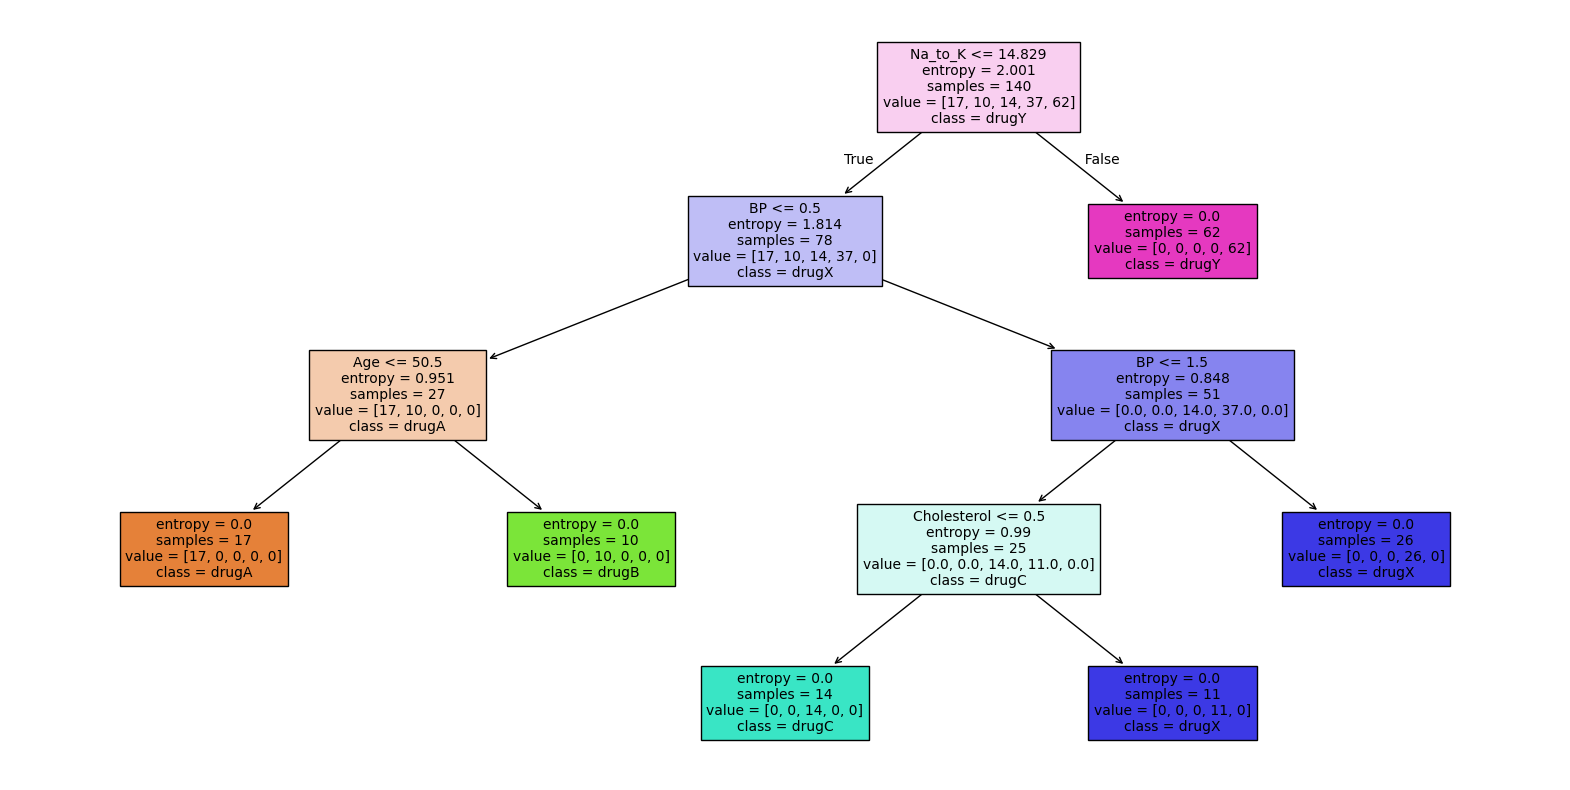

In [9]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(ID3, 
               feature_names=df.columns[0:5],  
               class_names=[str(i) for i in np.unique(y_train)],
               filled=True, 
               fontsize=10)

plt.savefig('../img/decision_tree.png', dpi=1080, bbox_inches='tight')

plt.show()